In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Download the data files
!rm *.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station2_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station4_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station5_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station6_Revised_Final_Data.csv

In [3]:
# List of stations
stations = {
    'Station1_Revised_Final_Data.csv': 'Station 1',
    'Station2_Revised_Final_Data.csv': 'Station 2',
    'Station3_Revised_Final_Data.csv': 'Station 3',
    'Station4_Revised_Final_Data.csv': 'Station 4',
    'Station5_Revised_Final_Data.csv': 'Station 5',
    'Station6_Revised_Final_Data.csv': 'Station 6'
}

In [4]:
# Load and process data for each station
def load_rainfall_data(file, station_name, time = 'year', pivot = False):
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)
    
    if time == 'year':
        df['Group'] = df['Date'].dt.year
    elif time == 'month':
        df['Group'] = df['Date'].dt.to_period('M').astype(str)
    elif time == 'month_matrix':
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month_name()
        df['Month_num'] = df['Date'].dt.month
        monthly_totals = df.groupby(['Year', 'Month', 'Month_num'])['Ppt'].sum().reset_index()
        matrix = monthly_totals.pivot_table(index='Month', columns='Year', values='Ppt')
        ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                          'July', 'August', 'September', 'October', 'November', 'December']
        return matrix.reindex(ordered_months)
    else:
        raise ValueError("`by` must be 'year', 'month', or 'month_matrix'")

    totals = df.groupby('Group')['Ppt'].sum().reset_index()
    totals.columns = [time.title(), station_name]

    if pivot:
        return totals.set_index(time.title())
    return totals

In [5]:
# Merge all data into rainfall per year
rain_year_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'year')
    rain_year_df = df if rain_year_df is None else pd.merge(rain_year_df, df, on = 'Year', how = 'outer')
rain_year_df.set_index('Year', inplace=True)

In [6]:
rain_year_df.head()

,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6
Year,,,,,,
2015,488.400000,800.38,942.71,755.58,810.71,731.69
2016,476.870000,864.62,890.41,926.76,814.81,638.30
2017,604.050000,528.76,649.38,629.81,620.43,441.23
2018,891.553044,692.70,740.80,659.74,654.00,798.36
2019,480.710000,501.91,558.57,485.00,441.59,458.35


In [7]:
# Merge all data into rainfall per month
rain_month_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'month')
    rain_month_df = df if rain_month_df is None else pd.merge(rain_month_df, df, on = 'Month', how = 'outer')
rain_month_df.set_index('Month', inplace=True)

In [8]:
rain_month_df.head(10)

,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6
Month,,,,,,
2015-01,53.48,76.89,75.15,56.00,71.56,42.87
2015-02,4.29,5.05,5.33,4.79,3.30,3.04
2015-03,57.82,48.13,53.26,60.07,61.65,49.46
2015-04,58.92,64.74,74.66,65.52,99.30,55.11
2015-05,219.44,245.06,264.86,208.24,230.35,243.82
2015-06,56.63,50.79,89.64,73.63,26.89,41.14
2015-07,28.19,2.03,17.27,0.00,0.00,5.58
2015-08,1.01,4.06,15.74,20.32,10.16,18.79
2015-09,8.62,16.00,14.48,5.82,10.41,6.60


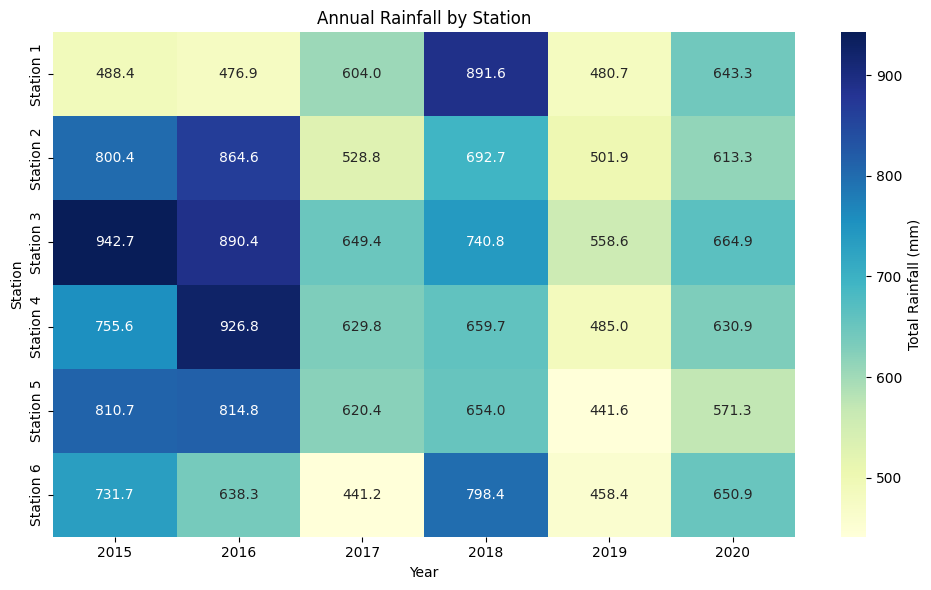

In [9]:
# Plot the heatmap by year
plt.figure(figsize=(10, 6))
sns.heatmap(rain_year_df.T, cmap = "YlGnBu", annot = True, fmt = ".1f", cbar_kws = {'label': 'Total Rainfall (mm)'})
plt.title("Annual Rainfall by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

## Hypothesis Test: Two-Sample T-Tests Between Stations

This section performs **independent two-sample t-tests** between each unique pair of weather stations to determine whether their **average annual rainfall** differs significantly.

---

### Hypotheses

For each station pair \( A \) and \( B \):

- **Null Hypothesis (H₀)**:  
  The mean annual rainfall at Station A is equal to the mean annual rainfall at Station B.  
  \( \mu_A = \mu_B \)

- **Alternative Hypothesis (H₁)**:  
  The mean annual rainfall at Station A is **not equal** to the mean at Station B.  
  \( \mu_A \ne \mu_B \)

---

### Test Details

- **Test used**: `scipy.stats.ttest_ind` (Welch’s t-test, assuming unequal variances)
- **Data**: Annual rainfall totals per station
- **Equal variances?** No (`equal_var=False`)
- **Significance level**: \( \alpha = 0.05 \)

---

### Results Interpretation

- Each row shows the comparison between two stations.
- The **p-value** tells us the probability of observing the data assuming the null hypothesis is true.
- If **p < 0.05**, the difference is considered **statistically significant**.
- In the current output:
  - **All p-values are > 0.05**
  - **We fail to reject the null hypothesis**
  - **Conclusion**: There is **no statistically significant difference** in average annual rainfall between any pair of stations.

In [10]:
from scipy.stats import ttest_ind
import itertools

results = []
for s1, s2 in itertools.combinations(rain_year_df.columns, 2):
    x = rain_year_df[s1].dropna()
    y = rain_year_df[s2].dropna()
    common = x.index.intersection(y.index)
    x_common = x.loc[common]
    y_common = y.loc[common]
    
    t_stat, p_val = ttest_ind(x_common, y_common, equal_var=False)
    
    results.append({
        "Station A": s1,
        "Station B": s2,
        "T-statistic": round(t_stat, 3),
        "P-value": round(p_val, 4),
        "Significant (p < 0.05)": "Yes" if p_val < 0.05 else "No"
    })

pd.DataFrame(results)


,Station A,Station B,T-statistic,P-value,Significant (p < 0.05)
0,Station 1,Station 2,-0.784,0.4513,No
1,Station 1,Station 3,-1.609,0.1389,No
2,Station 1,Station 4,-0.940,0.3696,No
3,Station 1,Station 5,-0.621,0.5484,No
4,Station 1,Station 6,-0.254,0.8049,No
5,Station 2,Station 3,-0.872,0.4038,No
6,Station 2,Station 4,-0.169,0.8693,No
7,Station 2,Station 5,0.177,0.8632,No
8,Station 2,Station 6,0.563,0.5859,No
9,Station 3,Station 4,0.698,0.5011,No


## Mann-Kendall Trend Test: Annual Rainfall at Each Station

This section applies the **Mann-Kendall test** to detect long-term trends in annual rainfall at each station.

---

### What is the Mann-Kendall Test?

The **Mann-Kendall test** is a non-parametric method used to identify **monotonic trends** (consistently increasing or decreasing) in a time series without assuming any particular distribution.

It is ideal for detecting **climate trends** like changes in rainfall or temperature over time.

---

### Hypotheses (Per Station)

For each station's annual rainfall series:

- **Null Hypothesis (H₀)**:  
  There is **no monotonic trend** in rainfall over time.

- **Alternative Hypothesis (H₁)**:  
  There **is a monotonic trend** (either increasing or decreasing) in annual rainfall.

---

### Test Details

- **Library used**: `pymannkendall`
- **Test**: `mk.original_test()`
- **Input**: Annual rainfall values per station
- **Significance level**: \( \alpha = 0.05 \)

---

### Output Explanation

| Column     | Description                                             |
|------------|---------------------------------------------------------|
| **Station** | Name of the weather station                            |
| **Trend**   | `increasing`, `decreasing`, or `no trend`              |
| **P-value** | Probability that the observed trend is due to chance   |
| **Significant** | "Yes" if p < 0.05, indicating a statistically significant trend |

---

### Interpretation of Your Results

- All stations returned **"no trend"** with **p-values > 0.05**
- This means the analysis **did not detect any statistically significant trends** in annual rainfall at any station
- Possible reasons:
  - Annual variation is high
  - Not enough years of data to detect a slow-moving trend

---

This analysis complements linear regression by using a **robust, distribution-free method** to assess long-term rainfall patterns.


In [11]:
import pymannkendall as mk

trend_results = []

for station in rain_year_df.columns:
    series = rain_year_df[station].dropna()
    
    # Perform Mann-Kendall test
    result = mk.original_test(series)
    
    trend_results.append({
        'Station': station,
        'Trend': result.trend,
        'P-value': round(result.p, 4),
        'Significant (p < 0.05)': 'Yes' if result.p < 0.05 else 'No'
    })

# Display as DataFrame
trend_df = pd.DataFrame(trend_results)
pd.DataFrame(trend_df)

,Station,Trend,P-value,Significant (p < 0.05)
0,Station 1,no trend,0.4524,No
1,Station 2,no trend,0.2597,No
2,Station 3,no trend,0.1329,No
3,Station 4,no trend,0.2597,No
4,Station 5,no trend,0.1329,No
5,Station 6,no trend,1.0000,No


### Kruskal-Wallis Test Summary for Rainfall Comparisons

The **Kruskal-Wallis H-test** is a non-parametric alternative to the one-way ANOVA. It assesses whether samples originate from the same distribution, without assuming normality. This is useful when rainfall data is skewed or contains outliers.

---

#### **Hypotheses**
- **Null Hypothesis (H₀):** The distributions of rainfall are the same across all groups being compared.
- **Alternative Hypothesis (H₁):** At least one group differs in distribution from the others.

---


#### **Interpretation**
- The **non-significant result** for rainfall differences across stations (p = 0.5490) suggests no statistically significant difference in distribution between stations.
- The **significant result** across years (p = 0.0014) indicates that at least one year had a rainfall distribution that was significantly different from the others.
- This supports the idea that **temporal variation** (year-to-year changes) is more pronounced than spatial variation (between stations) in rainfall patterns.


In [63]:
from scipy.stats import kruskal

# 1. Kruskal-Wallis test across stations (all years)
station_groups = [rain_year_df[station].dropna().values for station in rain_year_df.columns]
kruskal_stations_stat, kruskal_stations_p = kruskal(*station_groups)

# 2. Kruskal-Wallis test across years (all stations)
year_groups = [rain_year_df.loc[year].dropna().values for year in rain_year_df.index]
kruskal_years_stat, kruskal_years_p = kruskal(*year_groups)

# Display results
kruskal_results = pd.DataFrame({
    'Test': ['Across Stations (all years)', 'Across Years (all stations)'],
    'H-statistic': [round(kruskal_stations_stat, 3), round(kruskal_years_stat, 3)],
    'P-value': [round(kruskal_stations_p, 4), round(kruskal_years_p, 4)],
    'Significant (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [kruskal_stations_p, kruskal_years_p]]
})

print(kruskal_results)


                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)        4.003   0.5490                     No
1  Across Years (all stations)       19.784   0.0014                    Yes


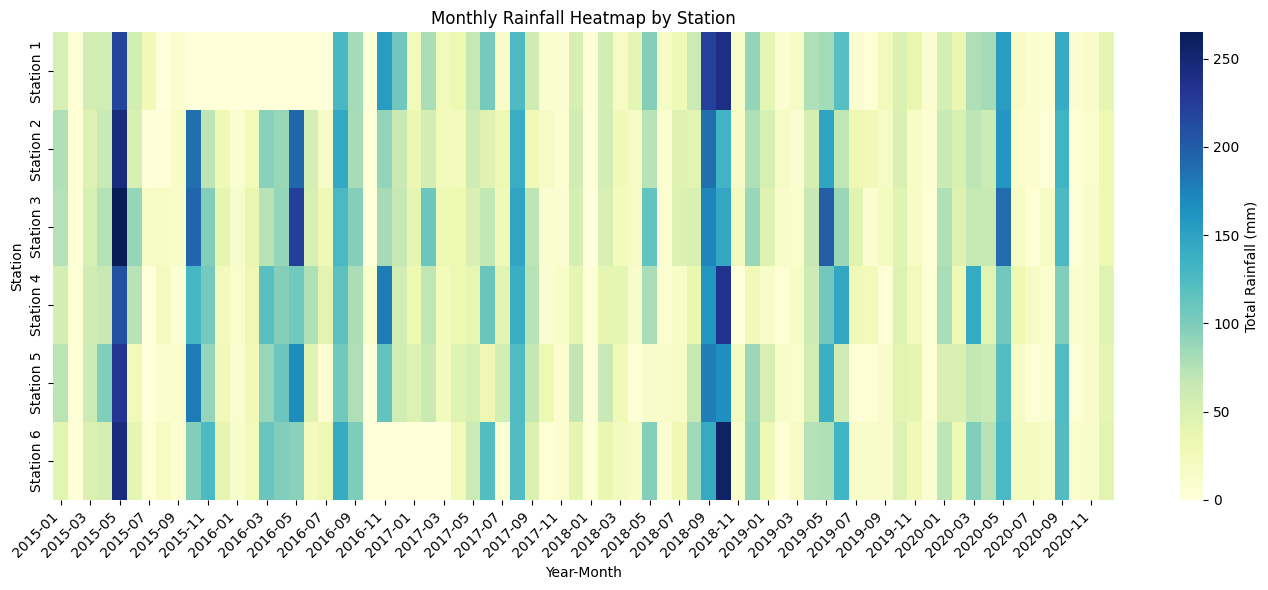

In [13]:
# Plot the heatmap by month
plt.figure(figsize = (14, 6))
sns.heatmap(rain_month_df.T, cmap = "YlGnBu", cbar_kws = {'label': 'Total Rainfall (mm)'})
plt.title("Monthly Rainfall Heatmap by Station")
plt.xlabel("Year-Month")
plt.ylabel("Station")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

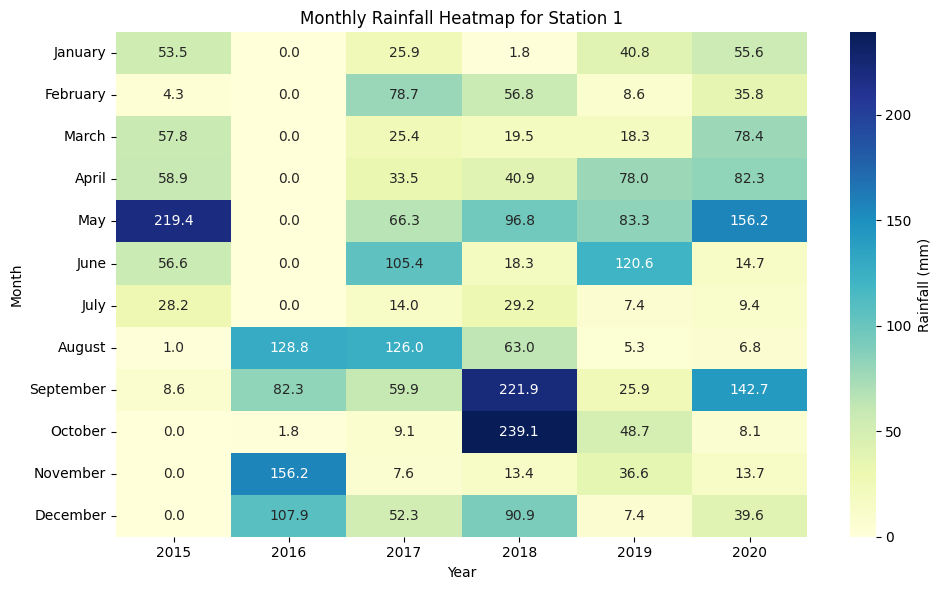

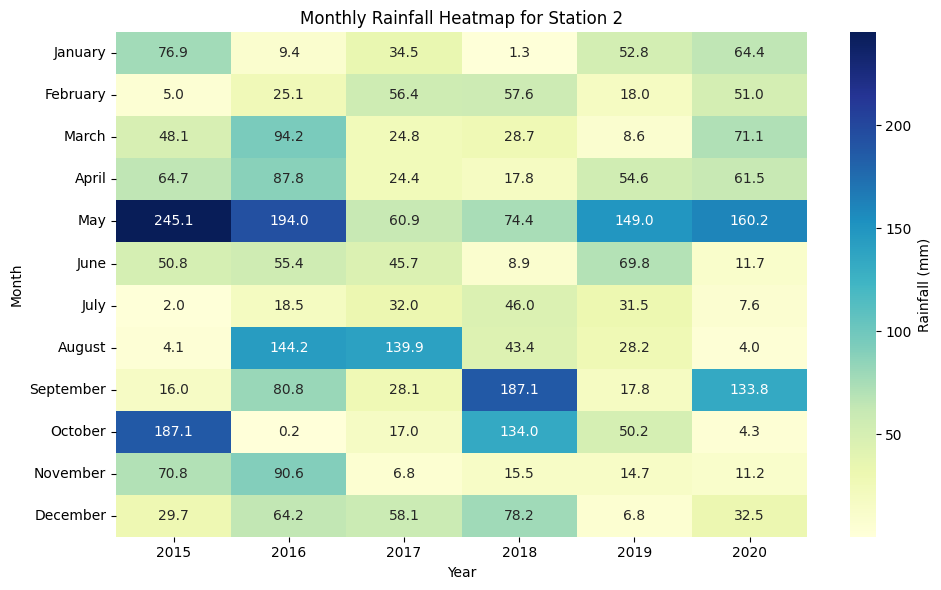

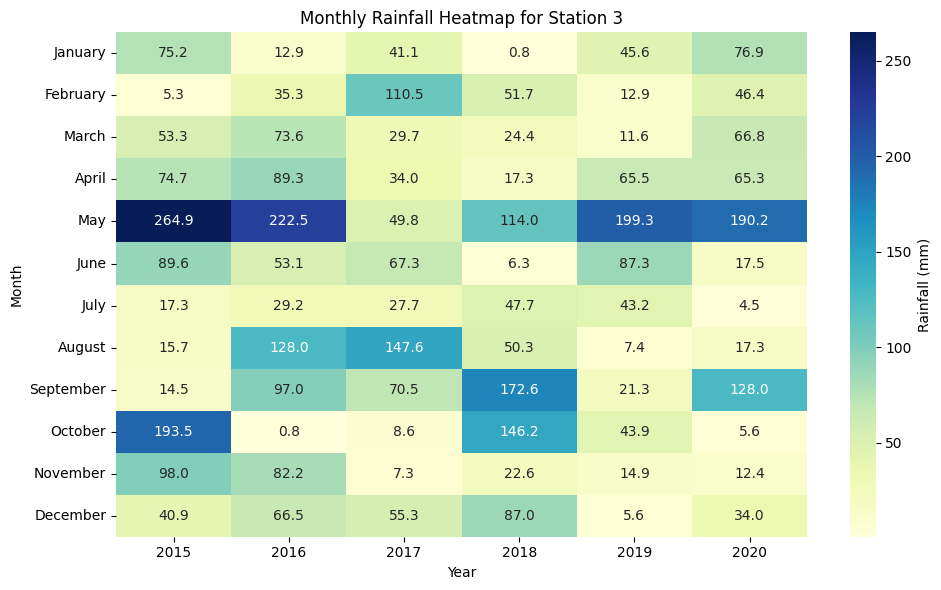

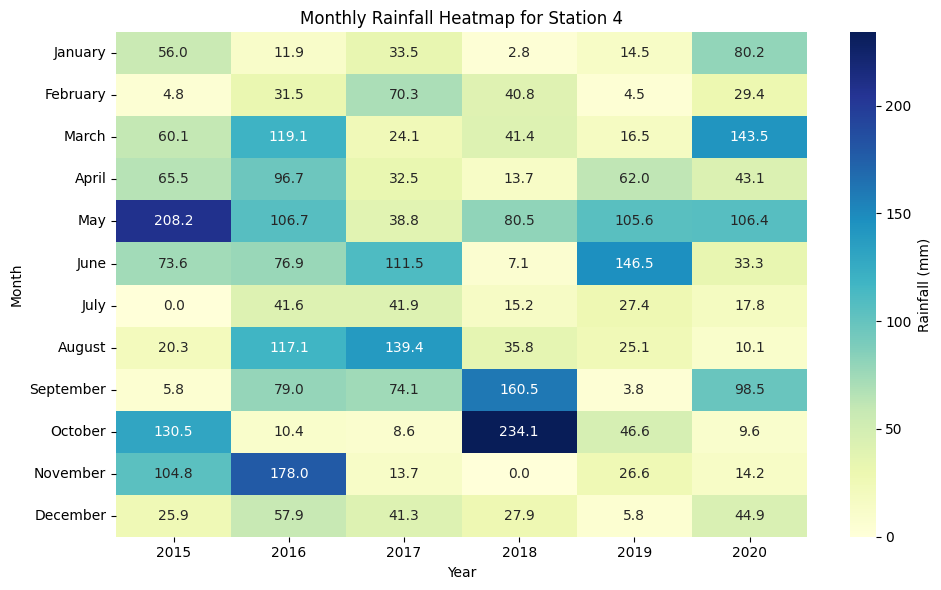

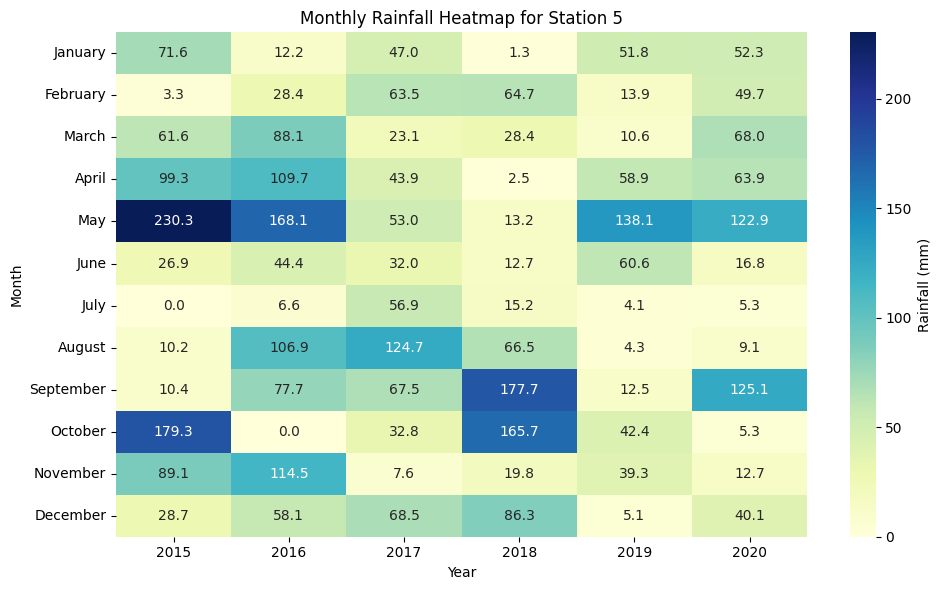

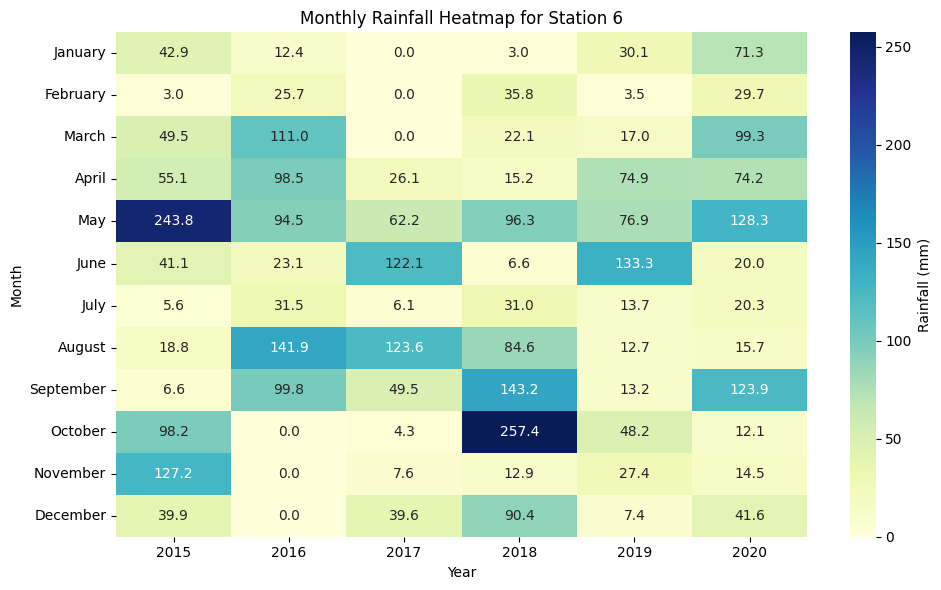

In [14]:
# Plot the heatmap for each station by month
for file, name in stations.items():
    matrix = load_rainfall_data(file, name, time = 'month_matrix')
    plt.figure(figsize = (10, 6))
    sns.heatmap(matrix, cmap = 'YlGnBu', annot = True, fmt = ".1f", cbar_kws = {'label': 'Rainfall (mm)'})
    plt.title(f'Monthly Rainfall Heatmap for {name}')
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

## Trend Analysis: Monthly Rainfall Over Time (Per Station)

This section uses **ordinary least squares (OLS) regression** to analyze whether monthly rainfall is increasing or decreasing over time at each station.

---

### Hypotheses (Per Station & Month)

For each station and each month (e.g., May at Station 3):

- **Null Hypothesis (H₀):**  
  There is **no trend** in rainfall over the years.  
  The slope of rainfall vs. year = 0.

- **Alternative Hypothesis (H₁):**  
  There is a **significant upward or downward trend** in rainfall.  
  The slope ≠ 0.

---

### Methodology

- For each station:
  - Extract the rainfall matrix by month and year using `.pivot_table()`.
  - For each month:
    - Fit a linear model: `Rainfall = β₀ + β₁ × Year`
    - Store the slope (β₁), p-value, and significance indicator
- Only months with at least 5 years of data are analyzed

---

### Results Interpretation

- **Slope**: Direction and rate of change in rainfall (mm/year)
  - Positive = rainfall is increasing
  - Negative = rainfall is decreasing
- **P-value**: Probability that the observed trend is due to chance
- **Significant (p < 0.05)**:
  - **Yes**: Evidence of a real increasing or decreasing trend
  - **No**: Cannot reject the null — no significant trend

---

### Key Findings

- Most month–station combinations showed **no statistically significant trends**.
- Only November at Station 3) had **p < 0.05**, suggesting isolated months with possible long-term shifts.
- Overall, **rainfall trends by month are not consistently significant across stations**, which may indicate high year-to-year variability or stable seasonal patterns.

---

This analysis helps identify subtle patterns in seasonal rainfall change — such as whether certain months are gradually becoming wetter or drier over the study period.


In [54]:
import statsmodels.api as sm
# Initialize container for results
monthly_trends = []

# Loop over each station
for file, name in stations.items():
    month_matrix = load_rainfall_data(file=file, station_name=name, time='month_matrix')

    for month in month_matrix.index:
        month_data = month_matrix.loc[month].dropna()

        if len(month_data) < 5:
            continue  # not enough years for trend analysis

        X = month_data.index.values.astype(int)
        X = sm.add_constant(X)
        y = month_data.values

        model = sm.OLS(y, X).fit()

        monthly_trends.append({
            'Station': name,
            'Month': month,
            'Slope': round(model.params[1], 3),
            'P-value': round(model.pvalues[1], 4),
            'Significant (p < 0.05)': 'Yes' if model.pvalues[1] < 0.05 else 'No'
        })

# Convert to DataFrame
monthly_trends_df = pd.DataFrame(monthly_trends)
significant_trends_df = monthly_trends_df[monthly_trends_df["Significant (p < 0.05)"] == "Yes"]

# Display or export
pd.DataFrame(monthly_trends_df)

,Station,Month,Slope,P-value,Significant (p < 0.05)
0,Station 1,January,3.107,0.6527,No
1,Station 1,February,4.605,0.6067,No
2,Station 1,March,4.343,0.5917,No
3,Station 1,April,10.231,0.1883,No
4,Station 1,May,-1.023,0.9622,No
...,...,...,...,...,...
67,Station 6,August,-12.632,0.4258,No
68,Station 6,September,12.011,0.4472,No
69,Station 6,October,-0.935,0.9735,No
70,Station 6,November,-13.604,0.2755,No


## Autocorrelation Test for Seasonality (ACF)

This section uses the **autocorrelation function (ACF)** to detect seasonal patterns in monthly rainfall data at each station.

---

### Why Use ACF?

The ACF helps identify whether rainfall patterns repeat at regular intervals — for example, **every 12 months**, which would indicate **annual seasonality**.

---

### Method

- Monthly rainfall matrices were flattened into 1D time series (month-by-month over years).
- The **autocorrelation at lag 12** was extracted to check for annual patterns.
- A correlation at lag 12 greater than the 95% confidence threshold was marked as **"Seasonal Signal: Yes"**.

---

### Output Table Columns

| Column            | Meaning                                              |
|-------------------|------------------------------------------------------|
| **Station**        | The rainfall station being analyzed                 |
| **Lag 12 ACF**     | Autocorrelation value at 12-month lag               |
| **Seasonal Signal**| Yes/No based on statistical threshold               |

---

### Interpretation

- **Yes** in the "Seasonal Signal" column suggests the station has recurring yearly rainfall patterns.
- **No** suggests **no strong or consistent seasonality** in rainfall.

This analysis gives a quick statistical check for seasonal dynamics at each location before deeper modeling.


<Figure size 1000x400 with 0 Axes>

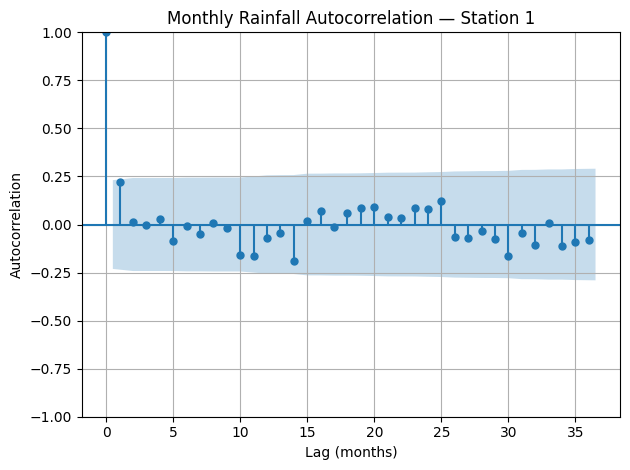

<Figure size 1000x400 with 0 Axes>

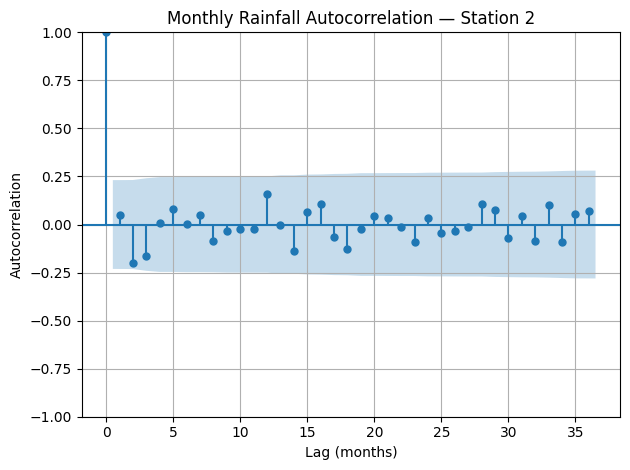

<Figure size 1000x400 with 0 Axes>

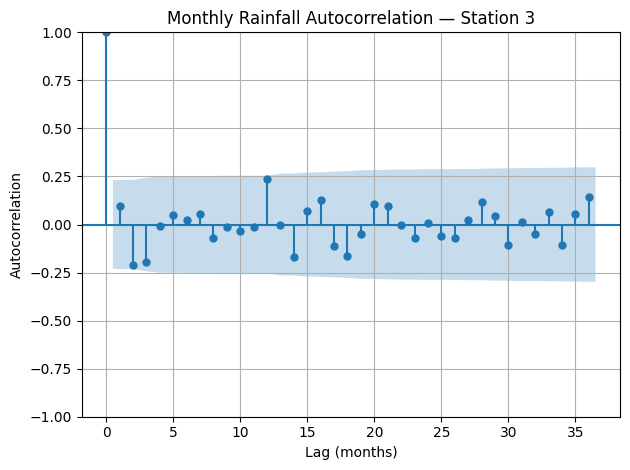

<Figure size 1000x400 with 0 Axes>

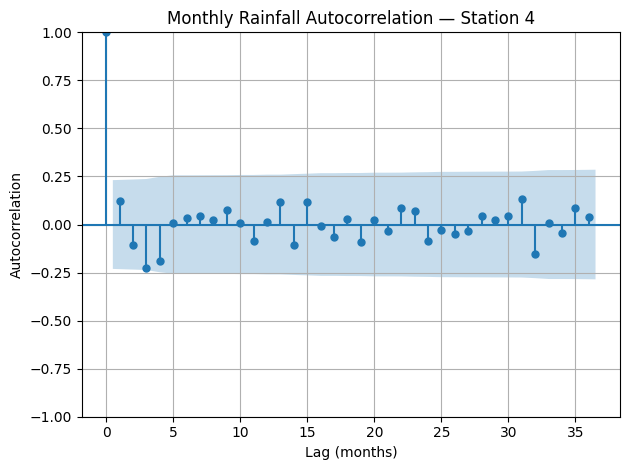

<Figure size 1000x400 with 0 Axes>

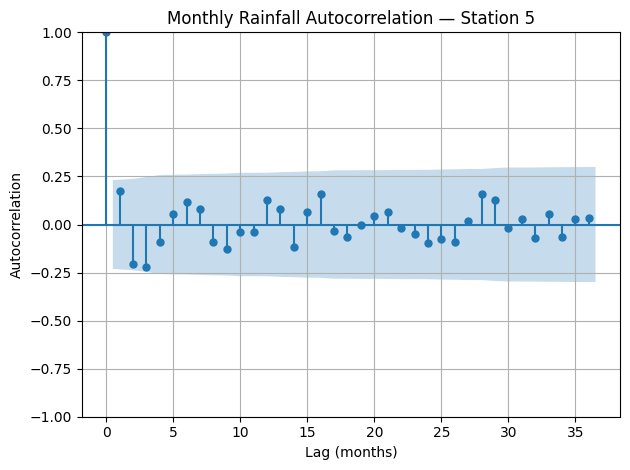

<Figure size 1000x400 with 0 Axes>

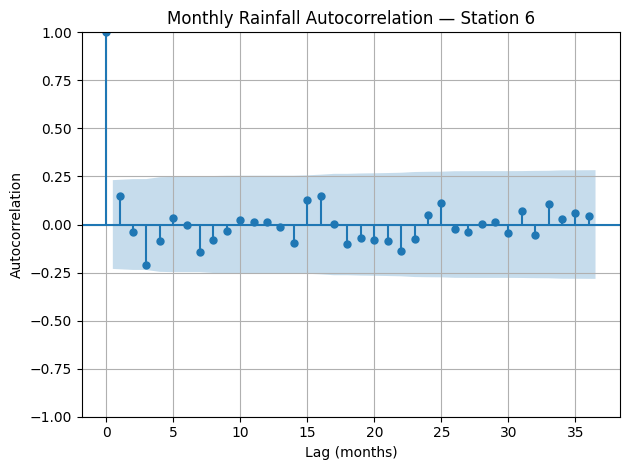

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Loop through each station and generate ACF plot for monthly rainfall
for file, station_name in stations.items():
    # Load monthly rainfall matrix (rows = months, cols = years)
    month_matrix = load_rainfall_data(file=file, station_name=station_name, time='month_matrix')
    
    # Skip if not enough data
    if month_matrix.empty or month_matrix.shape[1] < 3:
        print(f"Skipping {station_name} — insufficient data.")
        continue

    # Convert matrix into a 1D time series (month-by-month across years)
    monthly_series = month_matrix.T.values.flatten()
    monthly_series = pd.Series(monthly_series).dropna()

    # Plot ACF
    plt.figure(figsize=(10, 4))
    plot_acf(monthly_series, lags=36)  # Lags = months (3 years)
    plt.title(f"Monthly Rainfall Autocorrelation — {station_name}")
    plt.xlabel("Lag (months)")
    plt.ylabel("Autocorrelation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Kruskal-Wallis H Test: Monthly Rainfall Variation Across Stations

### Objective

To assess whether the **distribution of monthly rainfall** differs significantly across stations for each month of the year.

---

### Hypotheses (Per Month)

- **Null Hypothesis (H₀):** The distributions of rainfall across all stations are the same.
- **Alternative Hypothesis (H₁):** At least one station has a different distribution of rainfall for that month.

---

### Interpretation

None of the months showed statistically significant differences in rainfall distributions across stations (all p-values > 0.05). This implies that, based on the Kruskal-Wallis test, **there is no evidence that monthly rainfall differs across stations** for any specific month.

This aligns with the earlier findings that rainfall variability is not significantly different across locations, possibly due to regional coherence in weather systems.

---

### Conclusion

Given the **non-normal**, **skewed**, and **outlier-prone** nature of the rainfall data, the Kruskal-Wallis test is appropriate. The results suggest **no statistically significant difference in monthly rainfall across stations**, reinforcing the spatial consistency of seasonal precipitation patterns.


In [60]:
from scipy.stats import kruskal
import pandas as pd

# Container for results
kruskal_results = []

# Ordered list of months
months_ordered = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

# Loop through each month
for month in months_ordered:
    month_values = []

    # Collect rainfall data for this month from each station
    for file, name in stations.items():
        matrix = load_rainfall_data(file=file, station_name=name, time='month_matrix')

        if month in matrix.index:
            data = matrix.loc[month].dropna()
            if not data.empty:
                month_values.append(data.values)

    # Only run test if we have 2+ groups
    if len(month_values) > 1:
        h_stat, p_val = kruskal(*month_values)
        kruskal_results.append({
            "Month": month,
            "H-statistic": round(h_stat, 3),
            "P-value": round(p_val, 4),
            "Significant (p < 0.05)": "Yes" if p_val < 0.05 else "No"
        })

# Convert to DataFrame
kruskal_df = pd.DataFrame(kruskal_results)

print(kruskal_df)

        Month  H-statistic  P-value Significant (p < 0.05)
0     January        1.622   0.8985                     No
1    February        4.255   0.5133                     No
2       March        1.627   0.8980                     No
3       April        0.973   0.9647                     No
4         May        3.498   0.6236                     No
5        June        2.748   0.7388                     No
6        July        4.450   0.4867                     No
7      August        1.154   0.9492                     No
8   September        0.628   0.9867                     No
9     October        0.919   0.9688                     No
10   November        1.225   0.9424                     No
11   December        1.467   0.9168                     No


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e560f6b-1726-4372-a865-7294f65e8413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>